<a href="https://colab.research.google.com/github/VintaBytes/Ciencia-de-datos/blob/main/libros/ciencia-de-datos-con-python/volumen-04/cuadernos/CienciaDeDatos_Tomo3_Cuaderno25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# Capítulo 25 — Aprender sin etiquetas

Hasta aquí, la mayor parte del recorrido utilizó una variable objetivo `y`: una categoría en clasificación o un valor numérico en regresión. En este cuaderno trabajaremos de otra manera. Tendremos datos, pero ninguna respuesta conocida que el modelo deba aprender a predecir.

Retomaremos tres situaciones del capítulo teórico:

- clientes sin una columna que indique su “tipo”;
- muchas variables que queremos resumir para visualizar;
- viajes sin una etiqueta que diga cuáles son anómalos.

El propósito es construir una primera visión práctica del **aprendizaje no supervisado**. Usaremos K-Means, PCA e Isolation Forest como demostraciones panorámicas. Sus mecanismos y criterios de ajuste se desarrollarán con más profundidad en los capítulos correspondientes.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- distinguir un conjunto etiquetado de uno que contiene solamente `X`;
- explicar por qué el objetivo cambia cuando no existe `y`;
- reconocer agrupamiento, reducción de dimensionalidad y detección de anomalías;
- mostrar que la escala y la selección de variables afectan la estructura encontrada;
- interpretar los números de cluster como identificadores técnicos;
- describir grupos a partir de sus características;
- usar una representación bidimensional como ayuda exploratoria;
- diferenciar una anomalía estadística de una explicación sobre el caso;
- reconocer por qué la evaluación no supervisada necesita métricas, contexto y revisión humana.


## 1. Importar las herramientas

Usaremos NumPy y Pandas para construir y analizar los datos, Matplotlib para las visualizaciones y algunas herramientas de `scikit-learn` para mostrar las tres tareas principales.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Preparar clientes sin etiquetas

Crearemos un conjunto didáctico con información de comportamiento comercial. Las variables se inspiran directamente en el ejemplo del capítulo: frecuencia de compra, gasto promedio, antigüedad, cantidad de categorías y tiempo desde la última compra.

Los datos fueron construidos con patrones deliberados para que la demostración sea visible. Sin embargo, la tabla final no contiene una columna `tipo_cliente` ni una respuesta correcta. El algoritmo recibirá solamente variables descriptivas.


In [2]:
generador = np.random.default_rng(25)


def crear_clientes(
    cantidad,
    frecuencia_media,
    gasto_medio,
    recencia_media,
    antiguedad_media,
    categorias_media,
):
    return pd.DataFrame({
        "frecuencia_compra": generador.normal(
            frecuencia_media, 1.8, cantidad
        ),
        "gasto_promedio": generador.normal(
            gasto_medio, gasto_medio * 0.13, cantidad
        ),
        "dias_ultima_compra": generador.normal(
            recencia_media, max(4, recencia_media * 0.22), cantidad
        ),
        "antiguedad_meses": generador.normal(
            antiguedad_media, 8, cantidad
        ),
        "categorias_compradas": generador.normal(
            categorias_media, 0.8, cantidad
        ),
        "edad": generador.integers(20, 71, cantidad),
    })


datos_clientes = pd.concat([
    crear_clientes(45, 14, 95_000, 9, 32, 5.5),
    crear_clientes(40, 5, 180_000, 28, 20, 3.5),
    crear_clientes(35, 2.5, 52_000, 88, 55, 2.2),
], ignore_index=True)

datos_clientes["frecuencia_compra"] = (
    datos_clientes["frecuencia_compra"].clip(0.5).round(1)
)
datos_clientes["gasto_promedio"] = (
    datos_clientes["gasto_promedio"].clip(10_000).round(-2)
)
datos_clientes["dias_ultima_compra"] = (
    datos_clientes["dias_ultima_compra"].clip(1).round().astype(int)
)
datos_clientes["antiguedad_meses"] = (
    datos_clientes["antiguedad_meses"].clip(1).round().astype(int)
)
datos_clientes["categorias_compradas"] = (
    datos_clientes["categorias_compradas"].clip(1, 8).round().astype(int)
)

datos_clientes = (
    datos_clientes
    .sample(frac=1, random_state=25)
    .reset_index(drop=True)
)
datos_clientes.insert(
    0,
    "cliente",
    [f"CLI-{numero:03d}" for numero in range(1, len(datos_clientes) + 1)],
)

datos_clientes.head(8)


,cliente,frecuencia_compra,gasto_promedio,dias_ultima_compra,antiguedad_meses,categorias_compradas,edad
0,CLI-001,14.10,"82,400.00",10,19,6,65
1,CLI-002,13.60,"66,600.00",1,23,6,48
2,CLI-003,5.10,"165,000.00",15,31,3,31
3,CLI-004,14.20,"111,900.00",8,26,5,22
4,CLI-005,14.50,"108,000.00",2,24,5,58
5,CLI-006,11.50,"107,900.00",7,49,6,50
6,CLI-007,0.80,"184,000.00",18,20,3,64
7,CLI-008,15.90,"103,700.00",7,28,6,55


In [3]:
datos_clientes.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cliente               120 non-null    object 
 1   frecuencia_compra     120 non-null    float64
 2   gasto_promedio        120 non-null    float64
 3   dias_ultima_compra    120 non-null    int64  
 4   antiguedad_meses      120 non-null    int64  
 5   categorias_compradas  120 non-null    int64  
 6   edad                  120 non-null    int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 6.7+ KB


Tenemos 120 observaciones y seis variables descriptivas. La columna `cliente` es solo un identificador y no debe intervenir en el análisis.

En un problema supervisado escribiríamos algo como `X = datos[variables]` e `y = datos["objetivo"]`. Aquí esa segunda asignación no es posible: no existe una columna con la respuesta que deba predecirse.


In [4]:
variables_comportamiento = [
    "frecuencia_compra",
    "gasto_promedio",
    "dias_ultima_compra",
    "antiguedad_meses",
    "categorias_compradas",
]

X_clientes = datos_clientes[variables_comportamiento]

pd.DataFrame({
    "elemento": ["X", "y"],
    "contenido": [
        f"{X_clientes.shape[0]} filas y {X_clientes.shape[1]} variables",
        "No está disponible",
    ],
})


,elemento,contenido
0,X,120 filas y 5 variables
1,y,No está disponible


## 3. Explorar antes de modelar

No tener etiquetas no elimina la exploración. Revisaremos distribuciones y relaciones entre algunas variables antes de pedirle a un algoritmo que proponga una estructura.


In [5]:
datos_clientes[variables_comportamiento].describe().T


,count,mean,std,min,25%,50%,75%,max
frecuencia_compra,120.00,7.88,5.27,0.50,3.35,5.80,13.60,18.00
gasto_promedio,120.00,"111,281.67","52,195.49","37,100.00","60,300.00","100,850.00","165,000.00","213,400.00"
dias_ultima_compra,120.00,37.48,34.53,1.00,9.00,24.50,66.75,132.00
antiguedad_meses,120.00,34.93,15.99,2.00,23.00,32.00,45.25,72.00
categorias_compradas,120.00,3.95,1.55,1.00,3.00,4.00,5.00,7.00


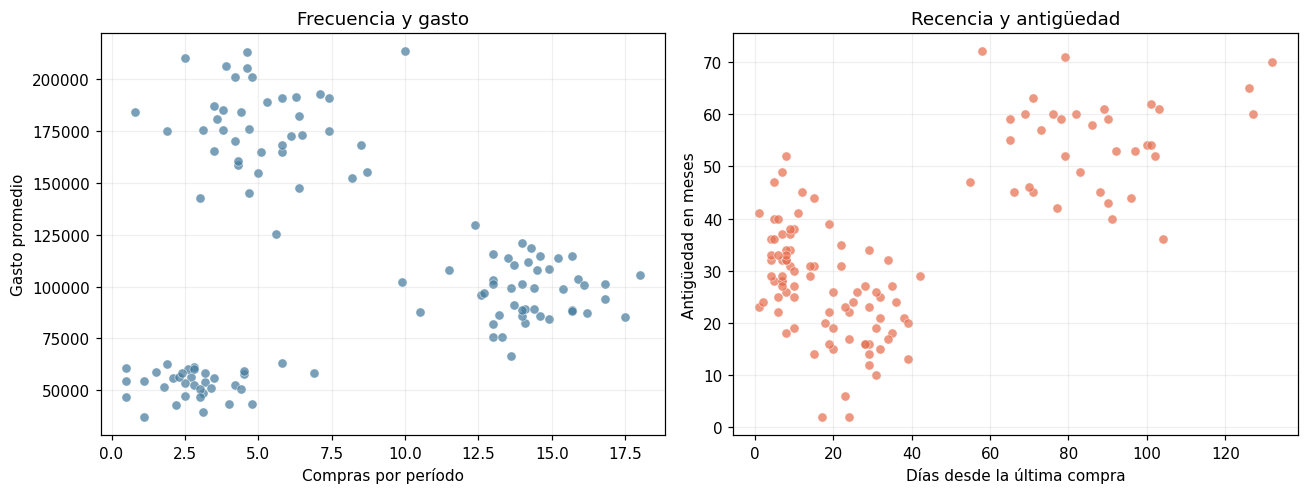

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

axes[0].scatter(
    datos_clientes["frecuencia_compra"],
    datos_clientes["gasto_promedio"],
    color="#457B9D",
    alpha=0.72,
    edgecolor="white",
    linewidth=0.4,
)
axes[0].set_xlabel("Compras por período")
axes[0].set_ylabel("Gasto promedio")
axes[0].set_title("Frecuencia y gasto")
axes[0].grid(alpha=0.2)

axes[1].scatter(
    datos_clientes["dias_ultima_compra"],
    datos_clientes["antiguedad_meses"],
    color="#E76F51",
    alpha=0.72,
    edgecolor="white",
    linewidth=0.4,
)
axes[1].set_xlabel("Días desde la última compra")
axes[1].set_ylabel("Antigüedad en meses")
axes[1].set_title("Recencia y antigüedad")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


Los gráficos sugieren que la tabla no es completamente homogénea, pero todavía no definen grupos verdaderos. Además, cada gráfico muestra solo dos variables. Un cliente puede parecer cercano a otro en un plano y diferente al considerar las demás columnas.

Esta es una primera diferencia con clasificación: no tenemos colores de clase conocidos con los que comprobar visualmente una separación.


## 4. La escala modifica la idea de parecido

En el capítulo teórico se advierte que una variable medida en pesos puede dominar a otra medida en cantidades. Lo mostraremos con tres clientes hipotéticos:

- A compra 4 veces y gasta $50.000;
- B compra 14 veces y gasta $55.000;
- C compra 4 veces y gasta $120.000.

Calcularemos la distancia desde A antes y después de estandarizar.


In [7]:
clientes_ejemplo = pd.DataFrame({
    "cliente": ["A", "B", "C"],
    "frecuencia_compra": [4, 14, 4],
    "gasto_promedio": [50_000, 55_000, 120_000],
}).set_index("cliente")

escalador_ejemplo = StandardScaler().fit(
    datos_clientes[["frecuencia_compra", "gasto_promedio"]]
)
ejemplo_escalado = escalador_ejemplo.transform(
    clientes_ejemplo
)

distancias = pd.DataFrame({
    "comparacion": ["A con B", "A con C"],
    "distancia_sin_escalar": [
        np.linalg.norm(clientes_ejemplo.loc["A"] - clientes_ejemplo.loc["B"]),
        np.linalg.norm(clientes_ejemplo.loc["A"] - clientes_ejemplo.loc["C"]),
    ],
    "distancia_escalada": [
        np.linalg.norm(ejemplo_escalado[0] - ejemplo_escalado[1]),
        np.linalg.norm(ejemplo_escalado[0] - ejemplo_escalado[2]),
    ],
})

distancias


,comparacion,distancia_sin_escalar,distancia_escalada
0,A con B,"5,000.01",1.91
1,A con C,"70,000.00",1.35


Sin escalar, unos pocos miles de pesos pesan mucho más que diez compras: la distancia queda casi completamente definida por `gasto_promedio`. Después de estandarizar, cada diferencia se interpreta en relación con la variabilidad habitual de su columna.

El escalado no determina qué variable debería ser conceptualmente importante. Solo evita que las unidades numéricas decidan por sí solas. La selección de variables continúa siendo una decisión humana.


## 5. Primera mirada al agrupamiento

Usaremos K-Means para pedir tres grupos. En este capítulo lo trataremos como una herramienta de demostración: recibe casos, compara similitudes y asigna un número de cluster. El próximo capítulo estudiará cómo construye esos grupos y cómo analizar la cantidad de clusters.

Primero estandarizamos las cinco variables de comportamiento. `edad` quedará afuera porque queremos explorar hábitos comerciales, no perfiles demográficos.


In [8]:
escalador_clientes = StandardScaler()
X_clientes_escalado = escalador_clientes.fit_transform(X_clientes)

agrupador = KMeans(
    n_clusters=3,
    n_init=20,
    random_state=25,
)
datos_clientes["cluster"] = agrupador.fit_predict(
    X_clientes_escalado
)

datos_clientes[["cliente", "cluster"] + variables_comportamiento].head(10)


,cliente,cluster,frecuencia_compra,gasto_promedio,dias_ultima_compra,antiguedad_meses,categorias_compradas
0,CLI-001,0,14.10,"82,400.00",10,19,6
1,CLI-002,0,13.60,"66,600.00",1,23,6
2,CLI-003,2,5.10,"165,000.00",15,31,3
3,CLI-004,0,14.20,"111,900.00",8,26,5
4,CLI-005,0,14.50,"108,000.00",2,24,5
5,CLI-006,0,11.50,"107,900.00",7,49,6
6,CLI-007,2,0.80,"184,000.00",18,20,3
7,CLI-008,0,15.90,"103,700.00",7,28,6
8,CLI-009,1,2.70,"56,400.00",92,53,2
9,CLI-010,0,14.00,"101,200.00",4,36,6


Los valores `0`, `1` y `2` no son categorías que existían antes. Tampoco forman un ranking: el cluster 2 no es mejor que el 1. Son identificadores técnicos que permiten separar los conjuntos propuestos por el algoritmo.

Para construir una interpretación debemos volver a las variables originales.


In [9]:
perfil_clusters = (
    datos_clientes
    .groupby("cluster")[variables_comportamiento]
    .mean()
    .round(1)
)
perfil_clusters.insert(
    0,
    "clientes",
    datos_clientes["cluster"].value_counts().sort_index(),
)

perfil_clusters


,clientes,frecuencia_compra,gasto_promedio,dias_ultima_compra,antiguedad_meses,categorias_compradas
cluster,,,,,,
0,45,14.20,"98,035.60",7.90,32.60,5.50
1,35,2.90,"53,280.00",86.60,54.60,2.30
2,40,5.10,"176,935.00",27.80,20.30,3.60


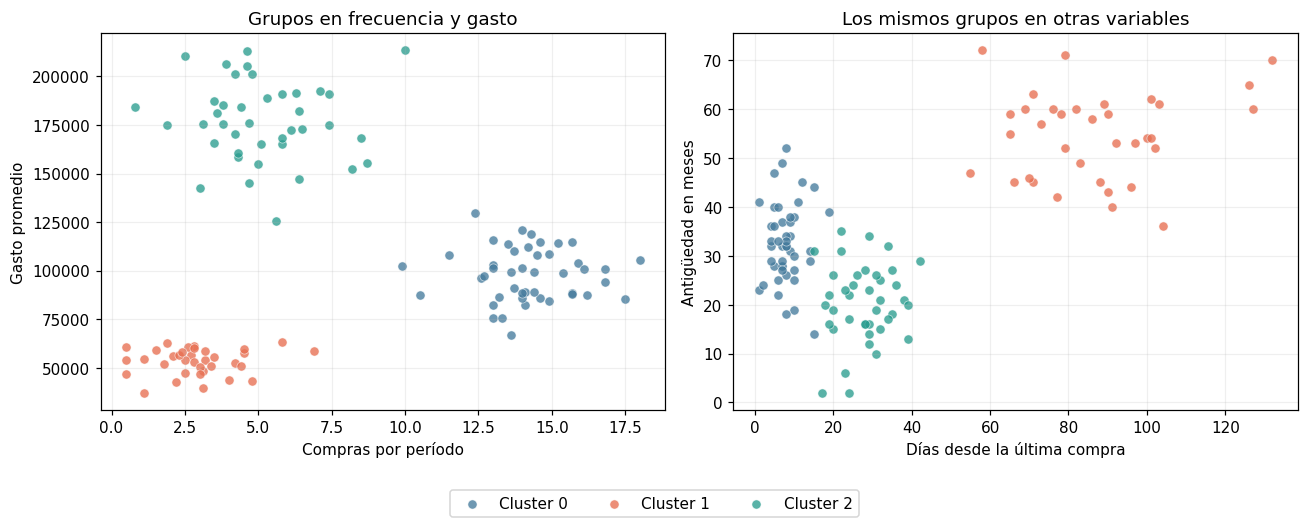

In [10]:
colores_clusters = {
    0: "#457B9D",
    1: "#E76F51",
    2: "#2A9D8F",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for cluster, grupo in datos_clientes.groupby("cluster"):
    color = colores_clusters[cluster]
    axes[0].scatter(
        grupo["frecuencia_compra"],
        grupo["gasto_promedio"],
        label=f"Cluster {cluster}",
        color=color,
        alpha=0.78,
        edgecolor="white",
        linewidth=0.4,
    )
    axes[1].scatter(
        grupo["dias_ultima_compra"],
        grupo["antiguedad_meses"],
        label=f"Cluster {cluster}",
        color=color,
        alpha=0.78,
        edgecolor="white",
        linewidth=0.4,
    )

axes[0].set_xlabel("Compras por período")
axes[0].set_ylabel("Gasto promedio")
axes[0].set_title("Grupos en frecuencia y gasto")
axes[0].grid(alpha=0.2)

axes[1].set_xlabel("Días desde la última compra")
axes[1].set_ylabel("Antigüedad en meses")
axes[1].set_title("Los mismos grupos en otras variables")
axes[1].grid(alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3)
plt.tight_layout(rect=(0, 0.09, 1, 1))
plt.show()


La tabla y los gráficos permiten proponer descripciones como “actividad frecuente”, “compras ocasionales de monto alto” o “baja actividad reciente”. Esos nombres no los produjo K-Means: son interpretaciones construidas al observar promedios y distribuciones.

Además, las descripciones valen para este conjunto y estas variables. No definen lo que cada persona “es” ni deberían convertirse automáticamente en decisiones sobre clientes individuales.


## 6. Los números de cluster son arbitrarios

Repetiremos el agrupamiento con otra inicialización. Los conjuntos pueden ser muy parecidos y, aun así, recibir números diferentes. Por eso nunca debemos interpretar el número mismo.


In [11]:
agrupador_alternativo = KMeans(
    n_clusters=3,
    n_init=1,
    random_state=2,
)
cluster_alternativo = agrupador_alternativo.fit_predict(
    X_clientes_escalado
)

pd.crosstab(
    datos_clientes["cluster"],
    cluster_alternativo,
    rownames=["Cluster original"],
    colnames=["Cluster alternativo"],
)


Cluster alternativo,0,1,2
Cluster original,,,
0,0,0,45
1,0,35,0
2,40,0,0


La tabla cruza ambas numeraciones. Una concentración en pocas celdas indica que muchos casos permanecen juntos aunque sus etiquetas numéricas cambien. Si hubiera diferencias mayores, también podrían deberse a otra solución encontrada por el algoritmo.

En ningún caso tiene sentido afirmar que una persona “subió” del cluster 0 al 2.


## 7. Cambiar las variables cambia la estructura

Ahora formularemos otra pregunta: en lugar de agrupar por comportamiento comercial, usaremos solamente `edad` y `antiguedad_meses`. Seguiremos pidiendo tres grupos, pero el parecido estará definido de otra manera.


In [12]:
variables_alternativas = ["edad", "antiguedad_meses"]
X_alternativo = StandardScaler().fit_transform(
    datos_clientes[variables_alternativas]
)

cluster_alternativo_variables = KMeans(
    n_clusters=3,
    n_init=20,
    random_state=25,
).fit_predict(X_alternativo)

comparacion_variables = pd.crosstab(
    datos_clientes["cluster"],
    cluster_alternativo_variables,
    normalize="index",
    rownames=["Cluster por comportamiento"],
    colnames=["Cluster por edad y antigüedad"],
).round(2)

comparacion_variables


Cluster por edad y antigüedad,0,1,2
Cluster por comportamiento,,,
0,0.42,0.40,0.18
1,0.06,0.06,0.89
2,0.52,0.48,0.00


Cada fila se reparte entre los grupos de la segunda propuesta. El algoritmo no “se confundió”: respondió dos preguntas distintas.

Si queremos comprender hábitos de compra, edad y antigüedad quizá no sean suficientes. Si queremos estudiar trayectorias de clientes, podrían ser relevantes. La estructura útil depende del objetivo exploratorio y de las variables elegidas.


## 8. ¿Qué habría ocurrido sin escalado?

Repetiremos el agrupamiento con las variables originales. Como `gasto_promedio` contiene valores mucho mayores que las demás columnas, esperamos que influya de forma desproporcionada.


In [13]:
cluster_sin_escalar = KMeans(
    n_clusters=3,
    n_init=20,
    random_state=25,
).fit_predict(X_clientes)

comparacion_escala = pd.crosstab(
    datos_clientes["cluster"],
    cluster_sin_escalar,
    rownames=["Con escalado"],
    colnames=["Sin escalado"],
)

perfil_sin_escalar = (
    datos_clientes
    .assign(cluster_sin_escalar=cluster_sin_escalar)
    .groupby("cluster_sin_escalar")[variables_comportamiento]
    .mean()
    .round(1)
)

print("Cruce de asignaciones:")
print(comparacion_escala.to_string())
print("\nPerfiles obtenidos sin escalar:")
perfil_sin_escalar


Cruce de asignaciones:
Sin escalado   0   1   2
Con escalado            
0             42   0   3
1              0   0  35
2              1  39   0

Perfiles obtenidos sin escalar:


,frecuencia_compra,gasto_promedio,dias_ultima_compra,antiguedad_meses,categorias_compradas
cluster_sin_escalar,,,,,
0,14.10,"100,446.50",8.60,32.70,5.50
1,5.10,"178,253.80",27.70,20.20,3.60
2,3.70,"54,807.90",80.20,52.60,2.60


Los perfiles sin escalar quedan organizados principalmente por el gasto. Eso puede ser apropiado si la pregunta busca niveles de gasto, pero no si queremos equilibrar varias dimensiones del comportamiento.

El preprocesamiento no es una operación neutral: modifica qué diferencias puede considerar importantes el algoritmo.


## 9. Reducir muchas variables a dos dimensiones

Los dos gráficos anteriores eligieron columnas originales. Ahora usaremos PCA para resumir las cinco variables de comportamiento en dos componentes.

El pipeline reproduce el flujo presentado en la teoría: primero escala y después reduce. No estudiaremos todavía cómo se calculan las componentes; aquí nos interesa su función como representación compacta.


In [14]:
pipeline_reduccion = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
])

componentes = pipeline_reduccion.fit_transform(X_clientes)

datos_reducidos = pd.DataFrame(
    componentes,
    columns=["componente_1", "componente_2"],
)
datos_reducidos["cluster"] = datos_clientes["cluster"].to_numpy()

datos_reducidos.head()


,componente_1,componente_2,cluster
0,-1.80,-1.02,0
1,-1.69,-1.29,0
2,-0.31,1.22,2
3,-1.54,-0.64,0
4,-1.69,-0.66,0


In [15]:
pca_ajustado = pipeline_reduccion.named_steps["pca"]
varianza_componentes = pca_ajustado.explained_variance_ratio_

pd.DataFrame({
    "componente": ["Componente 1", "Componente 2", "Total conservado"],
    "proporcion_varianza": [
        varianza_componentes[0],
        varianza_componentes[1],
        varianza_componentes.sum(),
    ],
}).round(4)


,componente,proporcion_varianza
0,Componente 1,0.61
1,Componente 2,0.29
2,Total conservado,0.90


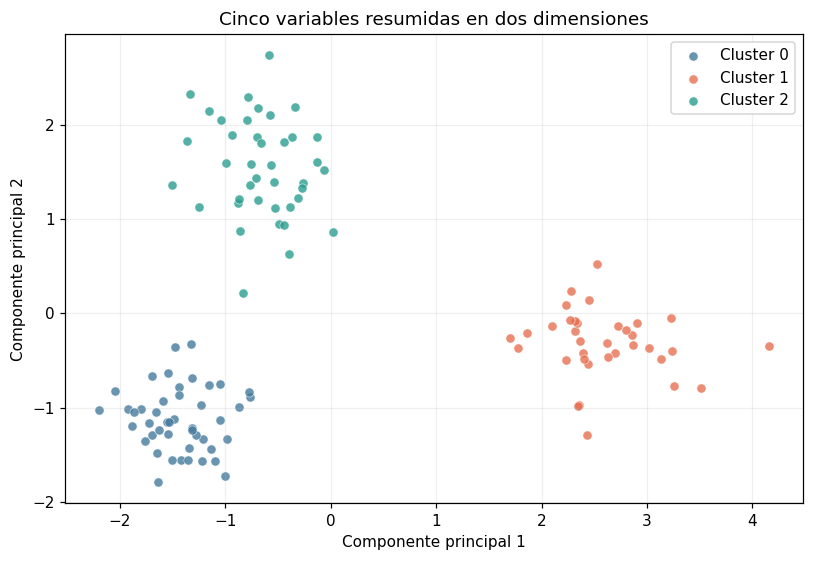

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 5.2))

for cluster, grupo in datos_reducidos.groupby("cluster"):
    ax.scatter(
        grupo["componente_1"],
        grupo["componente_2"],
        label=f"Cluster {cluster}",
        color=colores_clusters[cluster],
        alpha=0.8,
        edgecolor="white",
        linewidth=0.4,
    )

ax.set_xlabel("Componente principal 1")
ax.set_ylabel("Componente principal 2")
ax.set_title("Cinco variables resumidas en dos dimensiones")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()


La proporción acumulada indica cuánta variabilidad de las cinco columnas queda representada en el plano. El resto se pierde al resumir.

Las componentes no equivalen directamente a “gasto” o “frecuencia”: combinan varias columnas. El gráfico ayuda a explorar separaciones y superposiciones, pero no demuestra que existan categorías naturales ni conserva toda la información original.


## 10. Preparar viajes sin etiquetas de anomalía

Retomaremos otro ejemplo del capítulo: una combinación puede ser rara aunque cada valor por separado no sea el máximo o el mínimo.

Crearemos viajes habituales con distancia, duración y costo relacionados. Después agregaremos cinco casos preparados para representar combinaciones inusuales. La columna `origen_demo` se conservará solo para revisar la demostración: **no se entregará al modelo** y no representa una etiqueta disponible en un problema real.


In [17]:
generador_viajes = np.random.default_rng(250)
cantidad_habituales = 140

distancia = generador_viajes.uniform(1, 20, cantidad_habituales)
duracion = 4 + 2.7 * distancia + generador_viajes.normal(
    0, 4, cantidad_habituales
)
costo = 1_800 + 650 * distancia + generador_viajes.normal(
    0, 1_100, cantidad_habituales
)

viajes_habituales = pd.DataFrame({
    "distancia_km": distancia,
    "duracion_min": duracion,
    "costo": costo,
    "origen_demo": "Habitual generado",
})

viajes_preparados = pd.DataFrame({
    "distancia_km": [5, 18, 2, 15, 8],
    "duracion_min": [10, 7, 56, 45, 25],
    "costo": [16_500, 14_000, 4_000, 3_800, 17_500],
    "origen_demo": "Caso preparado",
})

datos_viajes = pd.concat(
    [viajes_habituales, viajes_preparados],
    ignore_index=True,
)
datos_viajes.insert(
    0,
    "viaje",
    [f"V-{numero:03d}" for numero in range(1, len(datos_viajes) + 1)],
)

datos_viajes[["distancia_km", "duracion_min", "costo"]] = (
    datos_viajes[["distancia_km", "duracion_min", "costo"]].round(1)
)

datos_viajes.tail(8)


,viaje,distancia_km,duracion_min,costo,origen_demo
137,V-138,3.70,17.30,"4,317.20",Habitual generado
138,V-139,18.80,52.10,"14,335.70",Habitual generado
139,V-140,1.90,9.90,"2,037.50",Habitual generado
140,V-141,5.00,10.00,"16,500.00",Caso preparado
141,V-142,18.00,7.00,"14,000.00",Caso preparado
142,V-143,2.00,56.00,"4,000.00",Caso preparado
143,V-144,15.00,45.00,"3,800.00",Caso preparado
144,V-145,8.00,25.00,"17,500.00",Caso preparado


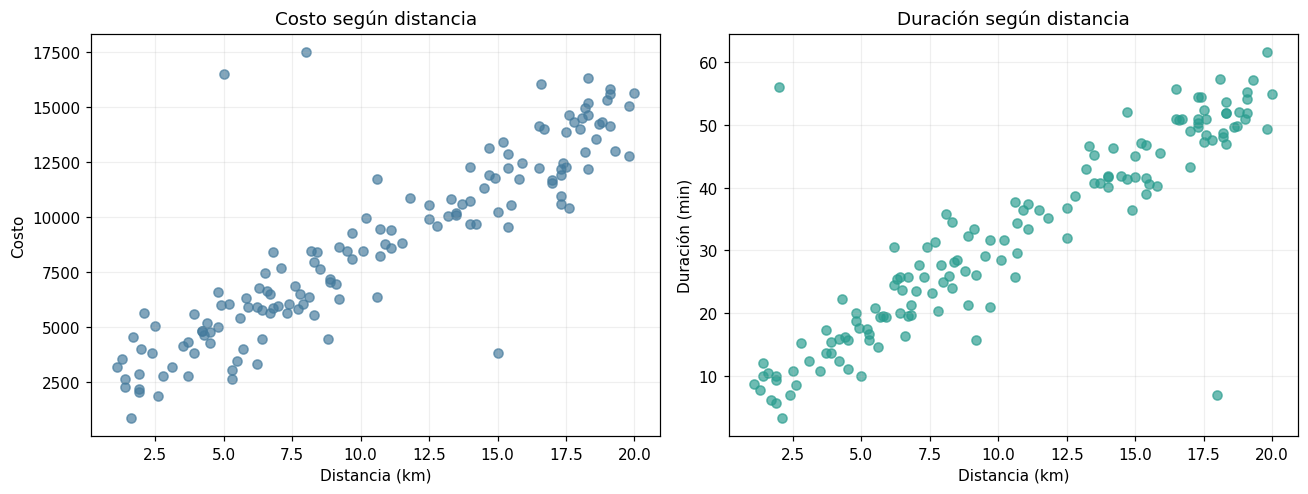

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

axes[0].scatter(
    datos_viajes["distancia_km"],
    datos_viajes["costo"],
    color="#457B9D",
    alpha=0.68,
)
axes[0].set_xlabel("Distancia (km)")
axes[0].set_ylabel("Costo")
axes[0].set_title("Costo según distancia")
axes[0].grid(alpha=0.2)

axes[1].scatter(
    datos_viajes["distancia_km"],
    datos_viajes["duracion_min"],
    color="#2A9D8F",
    alpha=0.68,
)
axes[1].set_xlabel("Distancia (km)")
axes[1].set_ylabel("Duración (min)")
axes[1].set_title("Duración según distancia")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


Los puntos habituales forman relaciones aproximadas: los viajes más largos suelen costar más y durar más. Algunos casos se alejan de esas relaciones. No necesariamente poseen el mayor costo, la mayor duración o la mayor distancia por separado.


## 11. Señalar casos inusuales con Isolation Forest

El modelo recibirá solo las tres variables numéricas. `contamination=0.04` expresa que esperamos marcar alrededor del 4% de los casos. No descubre la proporción real: es una decisión de modelado que influye directamente en la cantidad de alertas.


In [19]:
variables_viajes = ["distancia_km", "duracion_min", "costo"]

detector = IsolationForest(
    contamination=0.04,
    random_state=25,
)
prediccion_anomalia = detector.fit_predict(
    datos_viajes[variables_viajes]
)

datos_viajes["resultado"] = np.where(
    prediccion_anomalia == -1,
    "Revisar",
    "Habitual",
)
datos_viajes["puntaje_anomalia"] = -detector.score_samples(
    datos_viajes[variables_viajes]
)

datos_viajes["resultado"].value_counts()


resultado
Habitual    139
Revisar       6
Name: count, dtype: int64

In [20]:
casos_priorizados = (
    datos_viajes
    .sort_values("puntaje_anomalia", ascending=False)
    .head(12)
)

casos_priorizados[
    ["viaje", "distancia_km", "duracion_min", "costo",
     "origen_demo", "resultado", "puntaje_anomalia"]
]


,viaje,distancia_km,duracion_min,costo,origen_demo,resultado,puntaje_anomalia
141,V-142,18.00,7.00,"14,000.00",Caso preparado,Revisar,0.69
140,V-141,5.00,10.00,"16,500.00",Caso preparado,Revisar,0.68
142,V-143,2.00,56.00,"4,000.00",Caso preparado,Revisar,0.68
144,V-145,8.00,25.00,"17,500.00",Caso preparado,Revisar,0.67
143,V-144,15.00,45.00,"3,800.00",Caso preparado,Revisar,0.62
28,V-029,2.10,3.30,"5,635.00",Habitual generado,Revisar,0.61
80,V-081,19.80,61.60,"12,788.20",Habitual generado,Habitual,0.61
132,V-133,20.00,54.90,"15,653.10",Habitual generado,Habitual,0.58
119,V-120,1.60,10.40,853.60,Habitual generado,Habitual,0.57
21,V-022,1.90,5.70,"2,164.50",Habitual generado,Habitual,0.54


In [21]:
pd.crosstab(
    datos_viajes["origen_demo"],
    datos_viajes["resultado"],
    rownames=["Origen conocido solo en la demostración"],
    colnames=["Resultado del modelo"],
)


Resultado del modelo,Habitual,Revisar
Origen conocido solo en la demostración,,
Caso preparado,0,5
Habitual generado,139,1


La comparación es posible porque nosotros construimos los cinco casos y conservamos su origen. Aun así, `origen_demo` no demuestra que sean fraudes, errores o fallas: solo indica que fueron preparados para apartarse de las relaciones habituales.

En un problema real sin etiquetas, normalmente tendríamos una lista priorizada y necesitaríamos revisar cada caso con información del contexto.


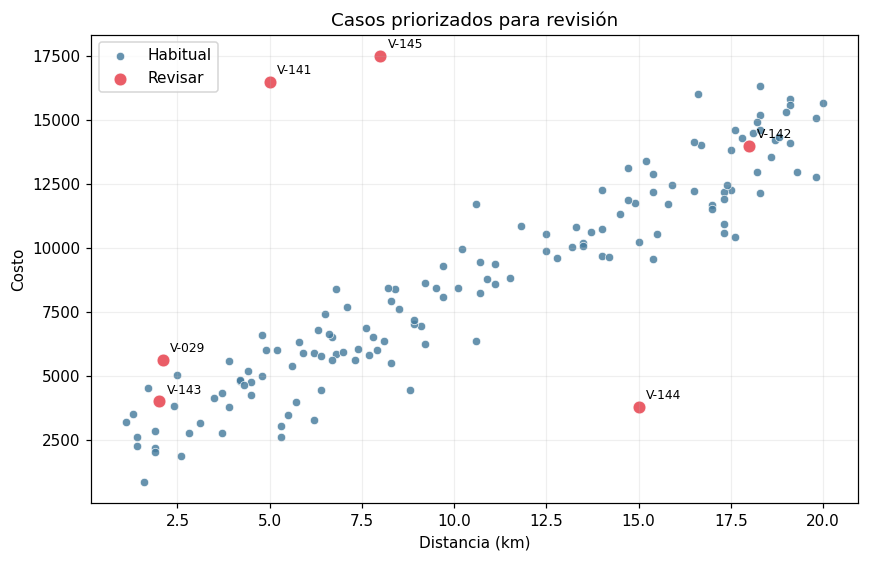

In [22]:
fig, ax = plt.subplots(figsize=(8, 5.2))

colores_anomalia = {
    "Habitual": "#457B9D",
    "Revisar": "#E63946",
}

for resultado, grupo in datos_viajes.groupby("resultado"):
    ax.scatter(
        grupo["distancia_km"],
        grupo["costo"],
        s=70 if resultado == "Revisar" else 30,
        color=colores_anomalia[resultado],
        label=resultado,
        alpha=0.82,
        edgecolor="white",
        linewidth=0.5,
    )

for _, fila in datos_viajes.query("resultado == 'Revisar'").iterrows():
    ax.annotate(
        fila["viaje"],
        (fila["distancia_km"], fila["costo"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xlabel("Distancia (km)")
ax.set_ylabel("Costo")
ax.set_title("Casos priorizados para revisión")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()


El gráfico muestra dos variables, pero Isolation Forest analizó tres. Un caso puede parecer razonable en costo y distancia, pero resultar raro al incorporar la duración.

La salida “Revisar” debe leerse literalmente como una prioridad de inspección. El algoritmo detectó rareza estadística; no explicó la causa.


## 12. La proporción esperada cambia las alertas

Probemos varias configuraciones de `contamination`. No buscamos elegir automáticamente una “ganadora”, sino observar que el parámetro materializa una decisión sobre cuántos casos se señalarán.


In [23]:
resultados_contaminacion = []

for proporcion in [0.02, 0.04, 0.08, 0.12]:
    modelo_demo = IsolationForest(
        contamination=proporcion,
        random_state=25,
    )
    marcas = modelo_demo.fit_predict(
        datos_viajes[variables_viajes]
    )
    resultados_contaminacion.append({
        "contamination": proporcion,
        "casos_marcados": int((marcas == -1).sum()),
        "porcentaje_marcado": (marcas == -1).mean(),
    })

pd.DataFrame(resultados_contaminacion).round(3)


,contamination,casos_marcados,porcentaje_marcado
0,0.02,3,0.02
1,0.04,6,0.04
2,0.08,12,0.08
3,0.12,18,0.12


Marcar más casos puede aumentar la posibilidad de encontrar eventos importantes, pero también genera más revisiones innecesarias. Marcar menos reduce el trabajo, aunque puede dejar pasar situaciones relevantes.

Sin etiquetas completas, esa decisión debe apoyarse en capacidad de revisión, costos, conocimiento del dominio y seguimiento de lo que ocurre con las alertas.


## 13. Actividad modificable

Elegí qué aspecto de los clientes querés explorar. Podés cambiar:

- las columnas de `variables_actividad`;
- la cantidad de grupos;
- el uso o no de escalado.

Después observá los tamaños y promedios. El objetivo no es encontrar un número “correcto” en un intento, sino comprobar cómo las decisiones modifican el resultado.


In [24]:
# Modificá estas opciones.
variables_actividad = [
    "frecuencia_compra",
    "gasto_promedio",
    "dias_ultima_compra",
]
cantidad_grupos = 3
usar_escalado = True

X_actividad = datos_clientes[variables_actividad]

if usar_escalado:
    X_actividad_modelo = StandardScaler().fit_transform(X_actividad)
else:
    X_actividad_modelo = X_actividad

grupos_actividad = KMeans(
    n_clusters=cantidad_grupos,
    n_init=20,
    random_state=25,
).fit_predict(X_actividad_modelo)

resumen_actividad = (
    datos_clientes
    .assign(grupo_actividad=grupos_actividad)
    .groupby("grupo_actividad")[variables_actividad]
    .agg(["count", "mean"])
    .round(1)
)

resumen_actividad


frecuencia_compra       gasto_promedio             \
                            count  mean          count       mean   
grupo_actividad                                                     
0                              45 14.20             45  98,035.60   
1                              35  2.90             35  53,280.00   
2                              40  5.10             40 176,935.00   

                dias_ultima_compra        
                             count  mean  
grupo_actividad                           
0                               45  7.90  
1                               35 86.60  
2                               40 27.80

## 14. Cómo evaluar sin una respuesta conocida

En este cuaderno pudimos inspeccionar tablas y gráficos, comparar decisiones y revisar casos preparados. En datos reales, la evaluación no supervisada suele combinar varias fuentes:

- **coherencia interna:** los casos de un grupo deberían parecerse según el criterio elegido;
- **estabilidad:** pequeños cambios razonables no deberían destruir por completo el resultado;
- **interpretabilidad:** los perfiles o dimensiones deberían poder analizarse;
- **utilidad:** el resultado debe ayudar a explorar, priorizar o tomar una decisión;
- **conocimiento del dominio:** personas que conocen el contexto deben revisar las conclusiones;
- **métricas técnicas:** pueden orientar, pero no garantizan por sí solas que el resultado sea significativo.

Una estructura matemáticamente ordenada puede ser inútil para la pregunta real. Del mismo modo, un gráfico atractivo puede ocultar información perdida durante la reducción.


## 15. Cuidado al comunicar los resultados

Es preferible decir:

> Con estas variables, este preprocesamiento y esta configuración, el modelo sugiere tres grupos de comportamiento.

No conviene afirmar:

> El modelo descubrió los tres tipos verdaderos de clientes.

Del mismo modo, “caso anómalo” significa que la observación es inusual para el modelo. No significa automáticamente fraude, falla, desinterés, culpabilidad o error.

Los datos no etiquetados tampoco son neutrales. La selección de variables, los faltantes, la escala, los sesgos del conjunto y los parámetros pueden modificar la estructura encontrada. Cuando el resultado afecta a personas, la revisión humana y la comunicación prudente son indispensables.


## 16. Síntesis

En este cuaderno:

- trabajamos con `X` sin una variable objetivo `y`;
- exploramos clientes sin categorías conocidas;
- comprobamos que la escala cambia la noción de distancia;
- obtuvimos grupos como una propuesta de organización;
- describimos clusters mediante variables originales;
- verificamos que sus números son arbitrarios;
- mostramos que cambiar las variables cambia la estructura;
- resumimos cinco columnas en dos componentes;
- usamos una visualización reducida sin confundirla con una prueba definitiva;
- detectamos viajes con combinaciones inusuales;
- interpretamos las anomalías como casos para revisar;
- observamos el efecto de la proporción esperada de anomalías;
- combinamos criterios técnicos con contexto y prudencia.

El aprendizaje no supervisado no aprende respuestas conocidas. Ayuda a construir nuevas formas de mirar los datos. Esa libertad lo vuelve potente para explorar, pero también exige más cuidado al interpretar y comunicar lo encontrado.


## Para pensar

1. ¿Por qué un número de cluster no debe interpretarse como una categoría con jerarquía?
2. ¿Cómo puede cambiar un agrupamiento si reemplazamos variables de compra por edad y ubicación?
3. ¿Qué información perdemos al representar cinco variables mediante solo dos componentes?
4. ¿Por qué un viaje marcado como anómalo no puede llamarse fraude sin una revisión posterior?
5. ¿Qué criterios combinarías para decidir si un resultado no supervisado es realmente útil?
